In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from src.preprocessing.dataset_loader import (
    build_dataset_index
)

from src.preprocessing.splitter import (
    create_stratified_split
)

from src.preprocessing.dataset_loader import (
    ChestXRayDataset
)

from src.preprocessing.dataloaders import (
    create_datasets,
    create_dataloaders
)

from src.preprocessing.transforms import (
    train_transform,
    val_transform
)

from src.federated.client import (
    FederatedClient
)

from src.federated.partition import (
    create_client_partitions
)

from src.federated.server import (
    FederatedServer
)

from src.federated.trainer import (
    federated_training
)

In [3]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [4]:
train_paths, train_labels = build_dataset_index(
    "../data/raw/train"
)

test_paths, test_labels = build_dataset_index(
    "../data/raw/test"
)

In [5]:
(
    X_train,
    X_val,
    y_train,
    y_val
) = create_stratified_split(
    train_paths,
    train_labels
)

In [6]:
(
    train_dataset,
    val_dataset,
    test_dataset
) = create_datasets(
    X_train,
    y_train,
    X_val,
    y_val,
    test_paths,
    test_labels
)

In [7]:
(
    train_loader,
    val_loader,
    test_loader
) = create_dataloaders(
    train_dataset,
    val_dataset,
    test_dataset,
    batch_size=32
)

In [8]:
val_dataset = ChestXRayDataset(
    image_paths=X_val,
    labels=y_val,
    transform=val_transform
)

In [9]:
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [10]:
client1 = FederatedClient(
    client_id="client_1",
    train_loader=train_loader,
    device=device
)

client2 = FederatedClient(
    client_id="client_2",
    train_loader=train_loader,
    device=device
)

client3 = FederatedClient(
    client_id="client_3",
    train_loader=train_loader,
    device=device
)

clients = [
    client1,
    client2,
    client3
]

In [11]:
clients_data = create_client_partitions(
    X_train,
    y_train,
    num_clients=5
)

In [12]:
client_datasets = {}

for client_id, data in clients_data.items():

    dataset = ChestXRayDataset(

        image_paths=data["paths"],

        labels=data["labels"],

        transform=train_transform

    )

    client_datasets[client_id] = dataset 

In [13]:
client_loaders = {}

for client_id, dataset in client_datasets.items():

    loader = DataLoader(

        dataset,

        batch_size=32,

        shuffle=True

    )

    client_loaders[client_id] = loader

In [14]:
for client_id, loader in client_loaders.items():

    print(
        client_id,
        len(loader.dataset)
    )

client_1 835
client_2 835
client_3 834
client_4 834
client_5 834


In [15]:
clients = []

for client_id, loader in client_loaders.items():

    client = FederatedClient(

        client_id=client_id,

        train_loader=loader,

        device=device

    )

    clients.append(
        client
    )

In [16]:
for client in clients:

    print(
        client.client_id,
        len(client.train_loader.dataset)
    )

client_1 835
client_2 835
client_3 834
client_4 834
client_5 834


In [17]:
server = FederatedServer(
    device=device
)

In [18]:
criterion = nn.CrossEntropyLoss()

In [19]:
history = federated_training(

    server=server,

    clients=clients,

    val_loader=val_loader,

    criterion=criterion,

    device=device,

    rounds=5,

    local_epochs=1

)


========== Round 1/5 ==========
6.806843884987757e-05 0.999087929725647
0.14272162318229675 0.9610356092453003
9.356297596241347e-06 0.9999525547027588
0.11659929156303406 0.9380330443382263
7.281342550413683e-05 0.999351441860199
0.13942763209342957 0.9478482604026794
3.840614954242483e-05 0.99979168176651
0.18479599058628082 0.9198282957077026
1.327256268268684e-05 0.9999861717224121
0.2827517092227936 0.9333106279373169
1.876508264331278e-07 0.9999995231628418
0.29354628920555115 0.9540043473243713
3.733102289515955e-07 0.9999953508377075
0.27443641424179077 0.9569413065910339
2.3969866447259847e-07 0.9999972581863403
0.34782350063323975 0.957135796546936
1.1097277763383318e-07 0.9999984502792358
0.3792435824871063 0.9556766152381897
5.877296302969626e-07 0.9999953508377075
0.3366171717643738 0.9650822877883911
3.4127032222386333e-07 0.9999971389770508
0.327492356300354 0.9524299502372742
5.368606252886821e-07 0.9999963045120239
0.3829764723777771 0.984394907951355
1.31381023038557

In [20]:
print("\nTraining Finished\n")

print(history)


Training Finished

{'train_loss': [0.4767206897338231, 0.37313839572447316, 0.32595100474578365, 0.3318958604777301, 0.3073188665288466], 'train_acc': [0.7703703703703704, 0.8157407407407407, 0.8468364197530864, 0.8528549382716049, 0.8585648148148148], 'val_loss': [1.5386865229317637, 0.4490437787590605, 0.42689435680707294, 0.29535114042686694, 0.2919312683921872], 'val_acc': [0.743939393939394, 0.7429924242424243, 0.7691287878787879, 0.8725378787878788, 0.8630681818181818]}


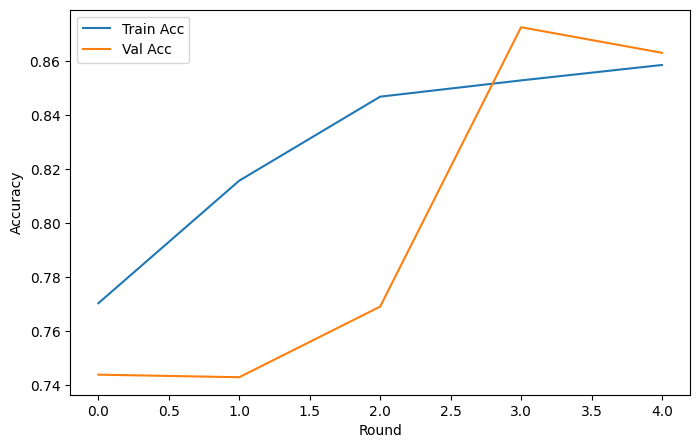

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")

plt.xlabel("Round")
plt.ylabel("Accuracy")

plt.legend()

plt.show()